# LeetCode #186: Reverse Words in a String II

https://leetcode.com/problems/reverse-words-in-a-string-ii/

## Comparison of Approaches
| Approach | Time | Space |
|---|---|---|
| Two-Pass Reverse ★ | O(n) | O(1) |
| Extra Array | O(n) | O(n) |

## Understanding the Methods
### Two-Pass Reverse (Optimal)
First reverse the entire character array, then reverse each individual word. This achieves the word-level reversal in-place. For example, `['t','h','e',' ','s','k','y']` → reverse all → `['y','k','s',' ','e','h','t']` → reverse each word → `['s','k','y',' ','t','h','e']`.

### Extra Array
Split by spaces, reverse the list of words, and flatten back. Simple but uses O(n) extra space, which violates the in-place constraint.

## Solutions

### C#

In [ ]:
public class Solution {
    public void ReverseWords(char[] s) {
        // Step 1: Reverse entire array
        Reverse(s, 0, s.Length - 1);
        // Step 2: Reverse each word
        int start = 0;
        for (int i = 0; i <= s.Length; i++) {
            if (i == s.Length || s[i] == ' ') {
                Reverse(s, start, i - 1);
                start = i + 1;
            }
        }
    }
    
    private void Reverse(char[] s, int left, int right) {
        while (left < right) {
            char temp = s[left];
            s[left] = s[right];
            s[right] = temp;
            left++;
            right--;
        }
    }
}

### Python

In [ ]:
class Solution:
    def reverseWords(self, s: list[str]) -> None:
        def reverse(left: int, right: int) -> None:
            while left < right:
                s[left], s[right] = s[right], s[left]
                left += 1
                right -= 1
        
        # Step 1: Reverse entire array
        reverse(0, len(s) - 1)
        # Step 2: Reverse each word
        start = 0
        for i in range(len(s) + 1):
            if i == len(s) or s[i] == ' ':
                reverse(start, i - 1)
                start = i + 1

### Go

In [ ]:
package main

func reverseWords(s []byte) {
    reverse := func(left, right int) {
        for left < right {
            s[left], s[right] = s[right], s[left]
            left++
            right--
        }
    }
    // Step 1: Reverse entire array
    reverse(0, len(s)-1)
    // Step 2: Reverse each word
    start := 0
    for i := 0; i <= len(s); i++ {
        if i == len(s) || s[i] == ' ' {
            reverse(start, i-1)
            start = i + 1
        }
    }
}

### Rust

In [ ]:
pub struct Solution;

impl Solution {
    pub fn reverse_words(s: &mut Vec<char>) {
        s.reverse();
        let n = s.len();
        let mut start = 0;
        for i in 0..=n {
            if i == n || s[i] == ' ' {
                s[start..i].reverse();
                start = i + 1;
            }
        }
    }
}

fn main() {
    let mut s: Vec<char> = "the sky is blue".chars().collect();
    Solution::reverse_words(&mut s);
    let result: String = s.into_iter().collect();
    println!("{}", result); // "blue is sky the"
}

## Example Scenarios

### 1. Common Case — Two Words Swap Positions

**Input:** `s = ['t','h','e',' ','s','k','y']`

Step 1: Reverse entire array to get `['y','k','s',' ','e','h','t']`. Step 2: Reverse each word — `yks` becomes `sky`, `eht` becomes `the`. Final: `['s','k','y',' ','t','h','e']`.

**WHY it's useful:** Classic two-pass reverse technique. Reversing all characters swaps word order but reverses each word's characters. The second pass fixes each word. Time: $O(n)$, Space: $O(1)$.

---

### 2. Slightly Complex — Three Words of Different Lengths

**Input:** `s = ['I',' ','l','o','v','e',' ','y','o','u']` (word lengths: 1, 4, 3)

After full reverse: `['u','o','y',' ','e','v','o','l',' ','I']`. Reverse each word: `uoy`$\to$`you`, `evol`$\to$`love`, `I`$\to$`I`. Result: `['y','o','u',' ','l','o','v','e',' ','I']`.

**WHY it's tricky:** Words have different lengths (1, 4, 3). After full reversal, word boundaries shift positions. The algorithm scans for spaces to find new word boundaries correctly.

---

### 3. Edge Case: Time Factor — Single Long Word ($n = 10^5$)

**Input:** `s = ['a','a','a',...,'a']` with $n = 100{,}000$ characters, no spaces.

Pass 1: Reverse entire array — $n/2 = 50{,}000$ swaps. Pass 2: Reverse the single word (indices 0 to 99,999) — another $n/2$ swaps. Total: exactly $n$ swaps across 2 passes.

**WHY it tests time:** No spaces means one giant word. Both passes perform $n/2$ swaps each. The algorithm runs in exactly 2 passes through the array, confirming $O(n)$ even in the worst case.

---

### 4. Edge Case: Space Factor — Maximum Word Count (All Single Characters)

**Input:** `s = ['a',' ','b',' ','c',' ',...,' ','z']` — 26 letters separated by spaces ($n = 51$).

After full reverse: `['z',' ','y',' ',...,' ','b',' ','a']`. Then reverse each 1-character word (no-op). 25 space-delimited boundaries must be found by the linear scan. Only $O(1)$ auxiliary space used (start index + loop counter).

**WHY it tests space:** Maximum number of words forces the most word-boundary detections. The algorithm uses only $O(1)$ extra space regardless of word count — no arrays, no stacks.

---

### 5. Almost-Impossible — Single Character Array

**Input:** `s = ['x']` ($n = 1$)

Reverse entire array `[0..0]`: `left = right = 0`, no swap. Scan for spaces: `i` goes from 0 to 1 (end), no space found. Reverse word `[0..0]`: no swap. Output: `['x']`, unchanged.

**WHY it's extreme:** The absolute minimum input size. Tests that the reverse function handles `left = right` (no-op) and the word scanner reaches the end without finding a space. Off-by-one errors commonly surface here — the loop condition `i <= s.length` (not `< s.length`) is critical to flush the last word.

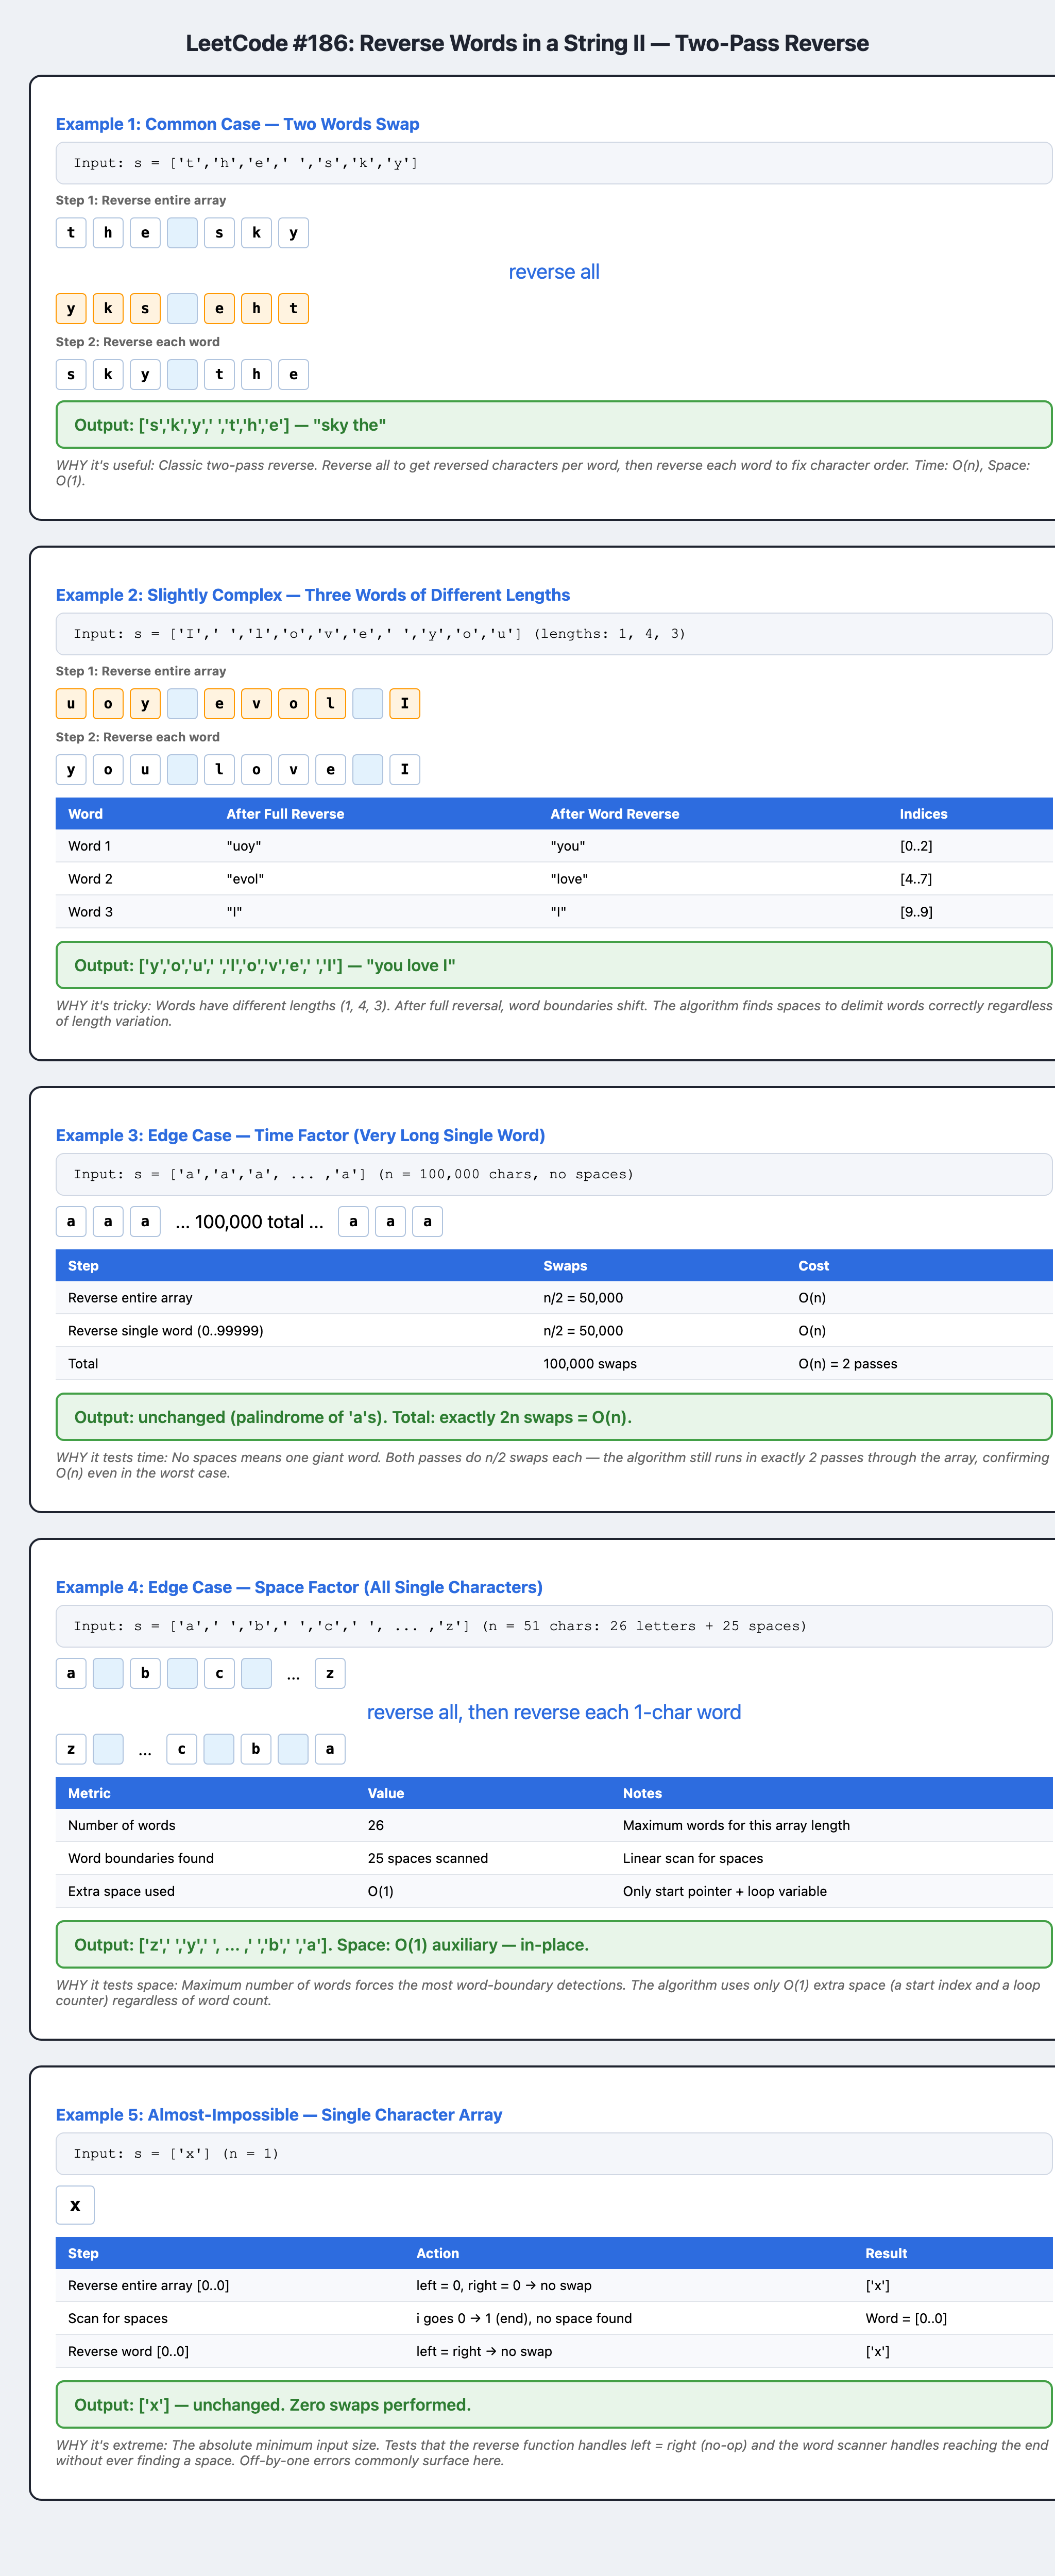